In [43]:
import pandas as pd

In [44]:
# Load JSONL file
df = pd.read_json('Dataset/resumes_dataset.jsonl', lines=True)

# First look at your data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (3500, 12)

Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source']

First 3 rows:
    ResumeID        Category              Name              Email  \
0  REAL_0001  Java Developer      Chad Griffin  contact@email.com   
1  REAL_0002  Java Developer    Melinda Thomas  contact@email.com   
2  REAL_0003  Java Developer  Shannon Mccarthy  contact@email.com   

                                               Phone     Location  \
0  94105 555 4321000          10                 ...  City, State   
1  17994568777  2017 2018 20152016       3       ...  City, State   
2  9  555 4321000      94105   8                 ...  City, State   

                                             Summary                   Skills  \
0  jessica claire montgomery street san francisco...  Python, SQL, Git, Linux   
1  jared arthur maica java developer 17994568777 ...  Python, SQL, Git, Linux   
2  jessica claire 9 resumesampl

In [45]:
# 1. How many unique job categories exist?
print(df['Category'].nunique())
print(df['Category'].value_counts())

36
Category
Java Developer               200
Python Developer             200
Data Science                 200
DevOps                       180
SQL Developer                180
Database                     150
Testing                      150
Web Designing                150
React Developer              150
Business Analyst             150
DotNet Developer             140
Software Developer           134
ETL Developer                120
Network Security Engineer    120
Full Stack Developer         102
SAP Developer                100
Digital Media                100
Cloud Engineer                92
Machine Learning Engineer     81
Frontend Developer            76
Backend Developer             76
AI Engineer                   71
Cybersecurity Analyst         66
QA Engineer                   61
Database Administrator        56
UI/UX Designer                51
Blockchain                    47
Site Reliability Engineer     46
Mobile Developer              46
System Administrator          4

In [46]:

# 2. Are there any missing/empty values?
print(df.isnull().sum())

# 3. Are there duplicate resumes?
print(f"\n Duplicates: {df.duplicated(subset=['Text']).sum()}")



ResumeID      0
Category      0
Name          0
Email         0
Phone         0
Location      0
Summary       0
Skills        0
Experience    0
Education     0
Text          0
Source        0
dtype: int64

 Duplicates: 196


In [47]:
# Before
print(f"Before removing duplicates: {df.shape}")

# Remove duplicates
df = df.drop_duplicates(subset=['Text'])

# Reset index
df = df.reset_index(drop=True)

# After
print(f"After removing duplicates: {df.shape}")
print(f"Removed: {3500 - len(df)} resumes")

Before removing duplicates: (3500, 12)
After removing duplicates: (3304, 12)
Removed: 196 resumes


In [48]:
# 4. How long are the resumes on average?
df['text_length'] = df['Text'].apply(lambda x: len(str(x).split()))
print(df['text_length'].describe())

count    3304.000000
mean      413.889225
std       358.230152
min        28.000000
25%       194.000000
50%       251.000000
75%       563.000000
max      6554.000000
Name: text_length, dtype: float64


In [49]:
# Check suspicious resumes
too_short = df[df['text_length'] < 50]
too_long = df[df['text_length'] > 2000]

print(f"Too short (under 50 words): {len(too_short)}")
print(f"Too long (over 2000 words): {len(too_long)}")

# Look at the too short ones
#pd.set_option('display.max_colwidth', None)
print("\n--- Sample Short Resumes ---")
print(too_short[['Category', 'text_length', 'Text']].head(3))

Too short (under 50 words): 3
Too long (over 2000 words): 11

--- Sample Short Resumes ---
           Category  text_length  \
886   SQL Developer           29   
972        Database           28   
2134  Digital Media           48   

                                                   Text  
886   mylee walters pl sql developer summary plsql y...  
972   phillip l waterman database management educati...  
2134  youremailaddressmailcom 0 123 456 789 ability ...  


In [50]:
df=df[df['text_length']>=50]
df=df.reset_index(drop=True)
print(f"After dropping short resumes: {df.shape}")
print(f"Removed: {3 } resumes")

After dropping short resumes: (3301, 13)
Removed: 3 resumes


In [51]:
# See a sample of long resumes
for i, row in too_long.head(3).iterrows():
    print(f"\n{'='*50}")
    print(f"Category: {row['Category']}")
    print(f"Length: {row['text_length']} words")
    # Show only first 200 words
    print(f"Text Preview: {' '.join(row['Text'].split()[:200])}")
    print(f"{'='*50}")


Category: Java Developer
Length: 3296 words
Text Preview: jessica claire 100 montgomery st 10th floor 555 4321000 resumesampleexamplecom linkedin url professional summary java developer 5 years experience system development life cycle process engineering design development deployment support testing using agile waterfall methodologies experience building microservices spring boot spring cloud experience managingscaledeploying applications pivotal cloud foundry expertise working various spring modules spring ioc spring batch spring mvc spring data jpa spring jdbc modules experienced building sophisticated distributed systems using nodejs resthypermedia web apis soa hibernate openjpa designed databases stored procedures performed analysis presented results using sql hands experience developing sql queries sql server databasedb2oracle knowledge cassandra nosql databases designed uml class diagrams sequencecollaboration diagrams activity diagrams using ms visio tool performance tuning jav

In [52]:
for i, row in too_long.iterrows():
    print(f"\n{'='*50}")
    print(f"Index: {i}")
    print(f"Category: {row['Category']}")
    print(f"Length: {row['text_length']} words")
    print(f"Text Preview: {' '.join(row['Text'].split()[:50])}")
    print(f"{'='*50}")


Index: 106
Category: Java Developer
Length: 3296 words
Text Preview: jessica claire 100 montgomery st 10th floor 555 4321000 resumesampleexamplecom linkedin url professional summary java developer 5 years experience system development life cycle process engineering design development deployment support testing using agile waterfall methodologies experience building microservices spring boot spring cloud experience managingscaledeploying applications pivotal cloud foundry expertise working various

Index: 268
Category: Python Developer
Length: 2354 words
Text Preview: jessica claire resumesampleexamplecom 555 4321000 professional summary highly motivated sales associate extensive customer service sales experience outgoing sales professional track record driving increased sales improving buying experience elevating company profile target market skills technical skills java technologies javaj2ee 1415161718 servlets jsp struts jdbc spring hibernate ejb jms mdbs jndi jpa

Index: 368
Catego

In [53]:
# Remove specific problematic long resumes by index
indices_to_remove = [268, 368, 1353, 1890]

print(f"Before removing bad long resumes: {df.shape}")

df = df.drop(index=indices_to_remove)
df = df.reset_index(drop=True)

print(f"After removing bad long resumes: {df.shape}")

Before removing bad long resumes: (3301, 13)
After removing bad long resumes: (3297, 13)


In [54]:

# First, let's find resumes with corrupted text patterns
def has_corrupted_text(text):
    # Check for common corruption patterns
    corrupted_patterns = ['iclaire', 'aclaired', 'eclaire', 'uclaire']
    return any(pattern in text.lower() for pattern in corrupted_patterns)

# Find corrupted resumes
df['is_corrupted'] = df['Text'].apply(has_corrupted_text)
corrupted = df[df['is_corrupted'] == True]

print(f"Corrupted resumes found: {len(corrupted)}")
print(corrupted[['Category', 'text_length']].head())

# Remove only corrupted ones
df = df[df['is_corrupted'] == False]
df = df.drop(columns=['is_corrupted'])
df = df.reset_index(drop=True)

print(f"\nFinal dataset after removing corrupted: {df.shape}")

Corrupted resumes found: 37
           Category  text_length
44   Java Developer          982
54   Java Developer          794
64   Java Developer         1143
152  Java Developer         1743
169  Java Developer          841

Final dataset after removing corrupted: (3260, 13)


/tmp/ipykernel_2703/2500282234.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')


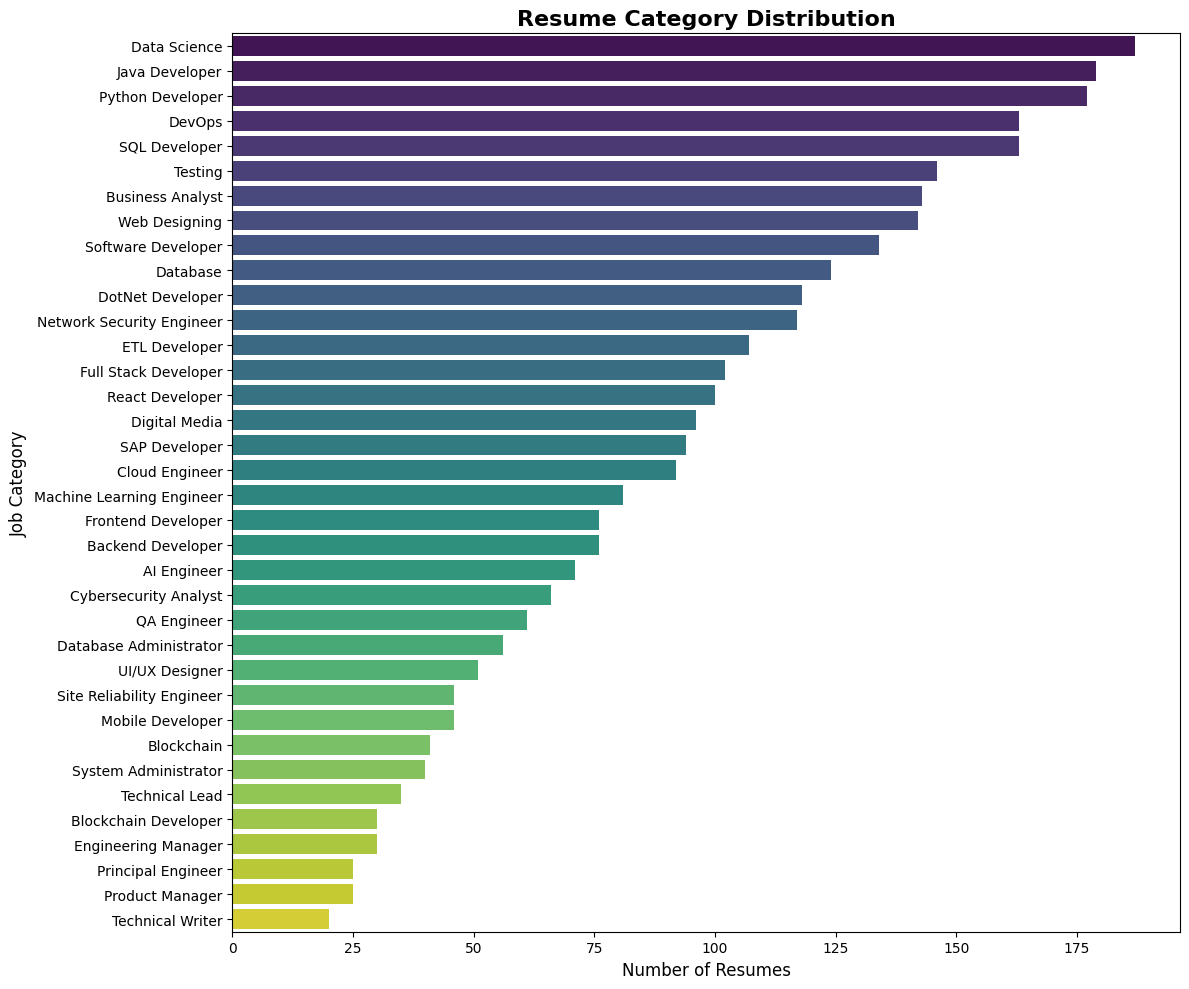

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')
plt.title('Resume Category Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Resumes', fontsize=12)
plt.ylabel('Job Category', fontsize=12)
plt.tight_layout()
plt.show()

In [56]:
print("="*60)
print("FINAL CLEAN DATASET SUMMARY")
print("="*60)
print(f"Total Resumes: {len(df)}")
print(f"Total Categories: {df['Category'].nunique()}")
print(f"\nText Length Statistics:")
print(df['text_length'].describe())
print(f"\nTop 10 Categories:")
print(df['Category'].value_counts().head(10))
print(f"\nBottom 5 Categories:")
print(df['Category'].value_counts().tail(5))
print("="*60)

FINAL CLEAN DATASET SUMMARY
Total Resumes: 3260
Total Categories: 36

Text Length Statistics:
count    3260.000000
mean      407.185276
std       350.860518
min        57.000000
25%       194.000000
50%       250.000000
75%       551.250000
max      6554.000000
Name: text_length, dtype: float64

Top 10 Categories:
Category
Data Science          187
Java Developer        179
Python Developer      177
DevOps                163
SQL Developer         163
Testing               146
Business Analyst      143
Web Designing         142
Software Developer    134
Database              124
Name: count, dtype: int64

Bottom 5 Categories:
Category
Blockchain Developer    30
Engineering Manager     30
Principal Engineer      25
Product Manager         25
Technical Writer        20
Name: count, dtype: int64


In [57]:
# Save cleaned dataset to avoid re-running cleaning every time
df.to_json('Dataset/cleaned_resumes.jsonl', orient='records', lines=True)
print("✅ Cleaned dataset saved to Dataset/cleaned_resumes.jsonl")

# Also save a backup as CSV (easier to inspect)
df.to_csv('Dataset/cleaned_resumes.csv', index=False)
print("✅ Backup CSV saved to Dataset/cleaned_resumes.csv")

✅ Cleaned dataset saved to Dataset/cleaned_resumes.jsonl
✅ Backup CSV saved to Dataset/cleaned_resumes.csv


In [58]:
import nltk

# Download required NLTK data (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

print("✅ NLTK data downloaded successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ NLTK data downloaded successfully!


In [59]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def clean_resume_text(text):
    """
    Clean and preprocess resume text for ML model
    
    Steps:
    1. Remove URLs, emails, special characters
    2. Convert to lowercase
    3. Remove stopwords
    4. Lemmatize words to root form
    """
    # Step 1: Convert to string (safety check)
    text = str(text)
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+\s*', ' ', text)
    
    # Step 3: Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Step 4: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Step 5: Lowercase
    text = text.lower()
    
    # Step 6: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 7: Tokenize and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    
    # Step 8: Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(w) for w in words]
    
    return " ".join(words)

In [60]:
# Test on one resume
sample_text = df['Text'].iloc[0]

print("BEFORE CLEANING:")
print(sample_text[:300])
print("\n" + "="*60 + "\n")

cleaned = clean_resume_text(sample_text)

print("AFTER CLEANING:")
print(cleaned[:300])
print(f"\nOriginal length: {len(sample_text.split())} words")
print(f"Cleaned length: {len(cleaned.split())} words")

BEFORE CLEANING:
jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professional summary highly skilled software development professional bringing 10 years software design development integration advanced knowledge java skills agile html xml jdbc tomcat work history senior jav


AFTER CLEANING:
jessica claire montgomery street san francisco resumesampleexamplecom professional summary highly skilled software development professional bringing year software design development integration advanced knowledge java skill agile html xml jdbc tomcat work history senior java developertech lead curre

Original length: 204 words
Cleaned length: 181 words


In [61]:
# Apply cleaning to all resumes
print("Cleaning all resumes... this may take 2-3 minutes")

df['cleaned_text'] = df['Text'].apply(clean_resume_text)

print(f"✅ Cleaning complete!")
print(f"Dataset shape: {df.shape}")

Cleaning all resumes... this may take 2-3 minutes
✅ Cleaning complete!
Dataset shape: (3260, 14)


In [62]:
# Check if any resumes became empty after cleaning
empty_after_cleaning = df[df['cleaned_text'].str.strip() == '']
print(f"Empty resumes after cleaning: {len(empty_after_cleaning)}")

# Compare before and after for first 3 resumes
for i in range(3):
    print(f"\n{'='*60}")
    print(f"Resume {i+1} - Category: {df['Category'].iloc[i]}")
    print(f"Original: {df['Text'].iloc[i][:100]}...")
    print(f"Cleaned: {df['cleaned_text'].iloc[i][:100]}...")
    

Empty resumes after cleaning: 0

Resume 1 - Category: Java Developer
Original: jessica claire montgomery street san francisco ca 94105 555 4321000 resumesampleexamplecom professio...
Cleaned: jessica claire montgomery street san francisco resumesampleexamplecom professional summary highly sk...

Resume 2 - Category: Java Developer
Original: jared arthur maica java developer 17994568777 linkedincominjamaica 2017 2018 20152016 jamaicagmailco...
Cleaned: jared arthur maica java developer linkedincominjamaica jamaicagmailcom twittercomjamaica enthusiasti...

Resume 3 - Category: Java Developer
Original: jessica claire 9 resumesampleexamplecom 555 4321000 montgomery street san francisco ca 94105 summary...
Cleaned: jessica claire resumesampleexamplecom montgomery street san francisco summary almost year experience...


In [63]:
# Save cleaned dataset with the new cleaned_text column
df.to_json('Dataset/cleaned_resumes.jsonl', orient='records', lines=True)
print("✅ Cleaned dataset saved!")

✅ Cleaned dataset saved!


In [64]:
print("="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"Total resumes: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample cleaned text:")
print(df['cleaned_text'].iloc[0][:200])
print("\n" + "="*60)

PREPROCESSING COMPLETE
Total resumes: 3260
Columns: ['ResumeID', 'Category', 'Name', 'Email', 'Phone', 'Location', 'Summary', 'Skills', 'Experience', 'Education', 'Text', 'Source', 'text_length', 'cleaned_text']

Sample cleaned text:
jessica claire montgomery street san francisco resumesampleexamplecom professional summary highly skilled software development professional bringing year software design development integration advanc

